# LSST Data Preview 2 — LSDB tutorial

In this tutorial, we will:
- Open the LSST Data Preview 2 HATS catalog in LSDB
- Select specific columns for analysis
- Plot the catalog
- Select a region of the sky with a cone search
- Restrict the catalog by querying column values
- Map a function across the catalog
- Compute the catalog
- Write the catalog to disk
- Read the catalog from disk
- Cross-match the catalog with another catalog

[TODO Add link]  
If you just want a minimal code example, see the **DP2 Starter** notebook.

Make sure you choose the **latest Weekly release** when you run this notebook on the RSP. This will give you the latest software versions with bug fixes and performance improvements.

## Setup

In [1]:
import lsdb

import astropy.units as u
from astropy.coordinates import SkyCoord
from upath import UPath
import matplotlib.pyplot as plt

In [2]:
# Setup
from dask.distributed import Client
client = Client(n_workers=4, memory_limit="4GiB", threads_per_worker=1)

/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46691 instead
  warnings.warn(


We can keep an eye on the Dask dashboard to monitor our compute usage.

In [3]:
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:46691/status


### Further reading
[Tutorial: Setting up a Dask Client](https://docs.lsdb.io/en/latest/tutorials/dask_client.html)  
[Tutorial: Dask cluster configuration tips](https://docs.lsdb.io/en/latest/tutorials/dask-cluster-tips.html)

## Open catalog

First, let's open the LSST DP2 catalog and plot its coverage.

In [4]:
# Open the LSST Object catalog
#base_path = UPath("/rubin/lsdb_data")
base_path = UPath("/astro/store/shire/hats/dash/hats/v30_0_6/")
cat = lsdb.open_catalog(base_path / "object_collection")
cat

,coord_dec,coord_decErr,coord_ra,coord_raErr,g_psfFlux,g_psfFluxErr,g_psfMag,g_psfMagErr,i_psfFlux,i_psfFluxErr,i_psfMag,i_psfMagErr,objectId,patch,r_psfFlux,r_psfFluxErr,r_psfMag,r_psfMagErr,refBand,shape_flag,shape_xx,shape_xy,shape_yy,tract,u_psfFlux,u_psfFluxErr,u_psfMag,u_psfMagErr,y_psfFlux,y_psfFluxErr,y_psfMag,y_psfMagErr,z_psfFlux,z_psfFluxErr,z_psfMag,z_psfMagErr,objectForcedSource
npartitions=110123,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 5, Pixel: 170",double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],"nested<band: [string], coord_dec: [double], co..."
"Order: 8, Pixel: 271295",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 196561",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 49141",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


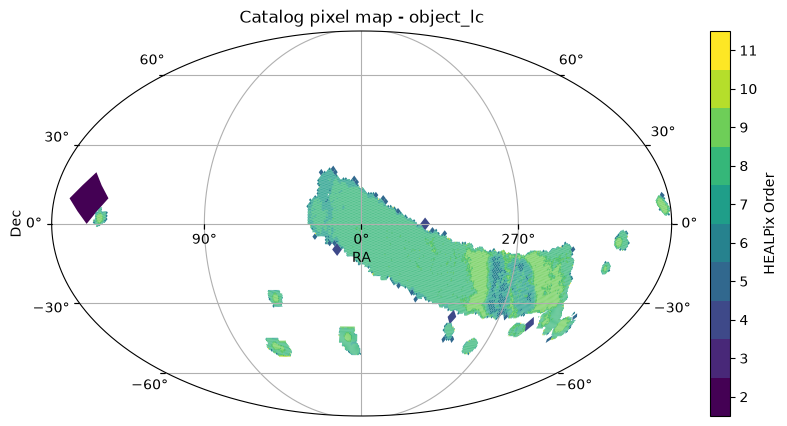

In [6]:
cat.plot_pixels();

### Further reading
[Tutorial: The Catalog Object](https://docs.lsdb.io/en/latest/tutorials/catalog_object.html)  
[Documentation: `Catalog`](https://docs.lsdb.io/en/latest/reference/catalog.html)

## Lazy evaluation

The catalog has been loaded *lazily*: no data has been read, only the catalog schema.

First we will filter the catalog down to only the data we need. Later, we will compute the catalog to download the data.

### Futher reading

[TODO Add link]  
Tutorial on RSP: **Why Lazy Evaluation?**  
[Tutorial: Lazy Operations in LSDB](https://docs.lsdb.io/en/latest/tutorials/lazy_operations.html)

## Choose columns

The Rubin catalog has 1304 data columns. We can choose only the columns we need for our analysis, which will speed up the compute step later. All columns are listed on [data.lsdb.io](https://data.lsdb.io/Rubin_DP1/object_collection).

Let's take a look at the default columns.

In [7]:
cat.columns

Index(['coord_dec', 'coord_decErr', 'coord_ra', 'coord_raErr', 'g_psfFlux',
       'g_psfFluxErr', 'g_psfMag', 'g_psfMagErr', 'i_psfFlux', 'i_psfFluxErr',
       'i_psfMag', 'i_psfMagErr', 'objectId', 'patch', 'r_psfFlux',
       'r_psfFluxErr', 'r_psfMag', 'r_psfMagErr', 'refBand', 'shape_flag',
       'shape_xx', 'shape_xy', 'shape_yy', 'tract', 'u_psfFlux',
       'u_psfFluxErr', 'u_psfMag', 'u_psfMagErr', 'y_psfFlux', 'y_psfFluxErr',
       'y_psfMag', 'y_psfMagErr', 'z_psfFlux', 'z_psfFluxErr', 'z_psfMag',
       'z_psfMagErr', 'objectForcedSource'],
      dtype='object')

We can choose columns using `lsdb.open_catalog(..., columns=columns)`. Note that `coord_ra` and `coord_dec` are always included.

In [8]:
cat = lsdb.open_catalog(base_path / "object_collection",
            columns=['g_psfFlux', 'g_psfMag', 'r_psfFlux'])
cat

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec
npartitions=110123,,,,,
"Order: 5, Pixel: 170",float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 8, Pixel: 271295",...,...,...,...,...
...,...,...,...,...,...
"Order: 7, Pixel: 196561",...,...,...,...,...
"Order: 6, Pixel: 49141",...,...,...,...,...


Choosing only these columns cut down the size of the catalog from 878.5 GB to 28.5 GB — less than 4%.

### Further reading
[Tutorial: column filtering](https://github.com/astronomy-commons/lsdb/blob/main/docs/tutorials/column_filtering.ipynb)  
[Documentation: `lsdb.open_catalog()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.open_catalog.html)


## Plot catalog

We can see the spatial density of the catalog with a sky plot:

/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


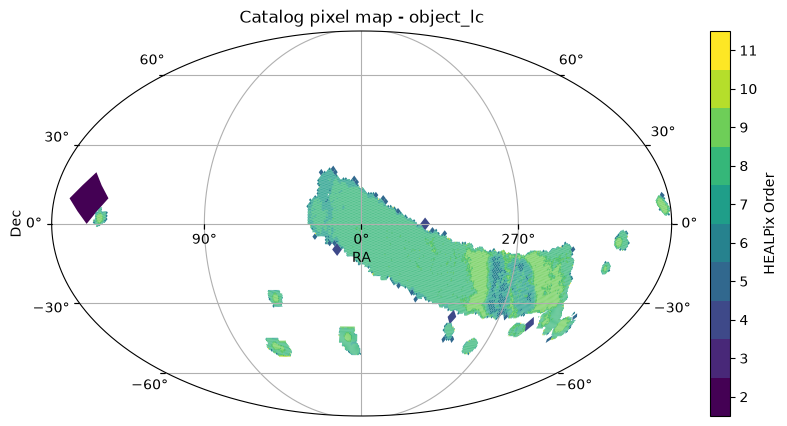

In [9]:
cat.plot_pixels();

We can also zoom in to a region in the sky. Let's focus near (ra=270, dec=-30).

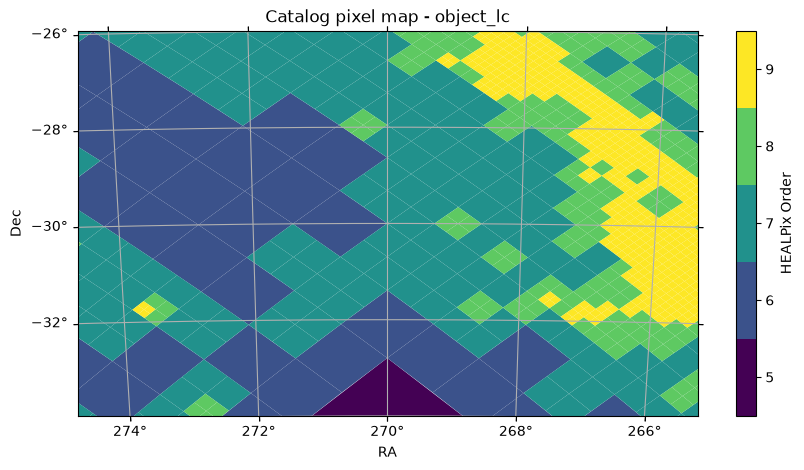

In [11]:
import astropy.units as u
fov = (8 * u.deg, 8 * u.deg)
center = SkyCoord(270 * u.deg, -30 * u.deg)
fig, ax = cat.plot_pixels(projection="AIT", fov=fov, center=center);

We can visualize the angular density in the same region:

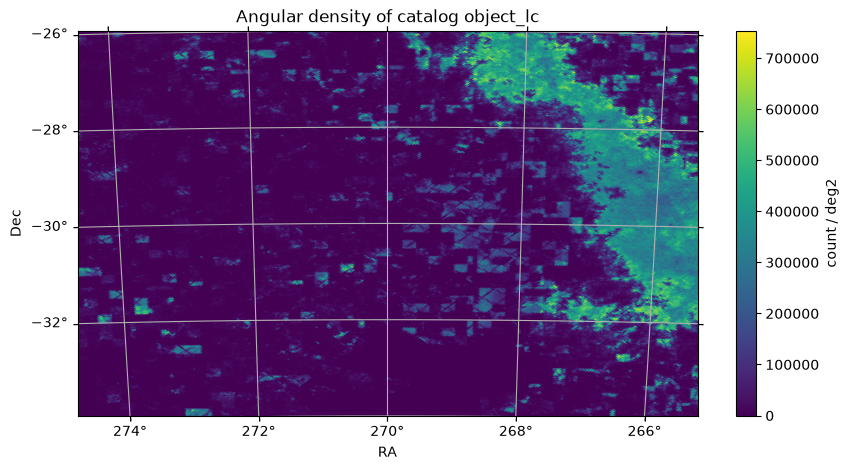

In [12]:
# plot_density() takes 1-2 minutes; skip this cell if you don't want to wait
import hats
hats.inspection.plot_density(cat.hc_structure, ec='face', projection="AIT", fov=fov, center=center);

### Further reading

[Tutorial: Plotting Results](https://docs.lsdb.io/en/latest/tutorials/pre_executed/plotting.html)  
[Documentation: `lsdb.Catalog.plot_pixels()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.plot_pixels.html)  
[Documentation: `hats.inspection`](https://hats.readthedocs.io/en/stable/autoapi/hats/inspection/index.html#hats.inspection.plot_density)

## Spatial filtering

Now let's restrict the catalog to the region where we zoomed in.

In [13]:
# Spatial filtering
cat = cat.cone_search(ra=270.0, dec=-30.0, radius_arcsec=2*3600)

In [14]:
cat

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec
npartitions=74,,,,,
"Order: 7, Pixel: 114910",float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 7, Pixel: 114911",...,...,...,...,...
...,...,...,...,...,...
"Order: 7, Pixel: 115488",...,...,...,...,...
"Order: 7, Pixel: 115489",...,...,...,...,...


The filtered catalog is significantly smaller: 

Catalog | Size
-------- | ------
Full DP2 | 878.5 GB
Selected columns | 28.5 GB
Selected columns and cone search | 19.1 MB

### Further reading:

[Tutorial: Region Selection](https://docs.lsdb.io/en/latest/tutorials/region_selection.html)  
[Documentation: `lsdb.Catalog.cone_search()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.cone_search.html#lsdb.catalog.Catalog.cone_search)

## Query

We can further filter objects using a query based on the column values.

The query syntax is the same as for [`pandas.DataFrame.query()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html), except that local variables cannot be used.

In [15]:
# Query to filter rows
cat = cat.query('g_psfFlux > 2.0 and r_psfFlux > 7.0')

Unlike spatial filtering, querying does not change the predicted size of the catalog. In reality, the catalog's size will decrease once we compute it.

In [16]:
cat

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec
npartitions=74,,,,,
"Order: 7, Pixel: 114910",float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 7, Pixel: 114911",...,...,...,...,...
...,...,...,...,...,...
"Order: 7, Pixel: 115488",...,...,...,...,...
"Order: 7, Pixel: 115489",...,...,...,...,...


### Further reading

[Tutorial: Row Filtering](https://docs.lsdb.io/en/latest/tutorials/row_filtering.html)  
[Documentation: `lsdb.Catalog.query()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.query.html#lsdb.catalog.Catalog.query)

## Mapping a function

We can map a function across all partitions (pixels) in the catalog using `lsdb.Catalog.map_partitions()`. From generating summary statistics per partition, to efficiently calculating transformations in parallel, this ability has many uses.

The mapping function takes in a dataframe that represents a partition—one row per object. It must return a dataframe. Some common usage patterns are:

- Add one or more columns to the dataframe and return it (e.g. calculate some attributes for each object, given the existing attributes). Rows still represent objects, and the number of rows remains the same.
- Return a subset of rows from the dataframe. Rows still represent objects, but the number of rows is less than the original partition.
- Return a dataframe of custom summary statistics for this partition (e.g. median value for each column). Rows no longer represent objects.

In [17]:
# Map a function
def g_minus_r_mapper(df):
    import numpy as np
    df['g_minus_r_mag'] = -np.log(df['g_psfFlux'] / df['r_psfFlux'])
    return df

cat = cat.map_partitions(g_minus_r_mapper)

### Further reading

[Tutorial: `map_partitions`](https://docs.lsdb.io/en/latest/tutorials/pre_executed/map_partitions.html)  
[Documentation: `lsdb.Catalog.map_partitions()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.map_partitions.html)

## Computing a catalog

All operations up to this point have been lazy, and have not downloaded data. To retrieve the data, we must **compute** the catalog.

First, we can use `lsdb.Catalog.head()` to retrieve only a few rows. This lets us make sure that everything looks right before executing a larger-scale computation of the whole catalog.

In [18]:
cat.head(5)

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,,
2021882992298765515,6312.816406,21.899443,950.743286,269.492478,-31.944853,-1.893093
2021885912268212287,722.161804,24.253414,9836.803711,269.525976,-31.936126,2.611637
2021885913480368752,1189.062744,23.711988,13368.254883,269.518602,-31.936637,2.419718
2021886052086887385,22559.029297,20.516699,95027.460938,269.499125,-31.911018,1.438030
2021886089486228703,684.218628,24.312014,15117.708984,269.493208,-31.897396,3.095345


We should now be able to see the task being executed in the Dask client. Check the Dask dashboard link near the beginning of this notebook and verify that you see activity. You should see something like this:

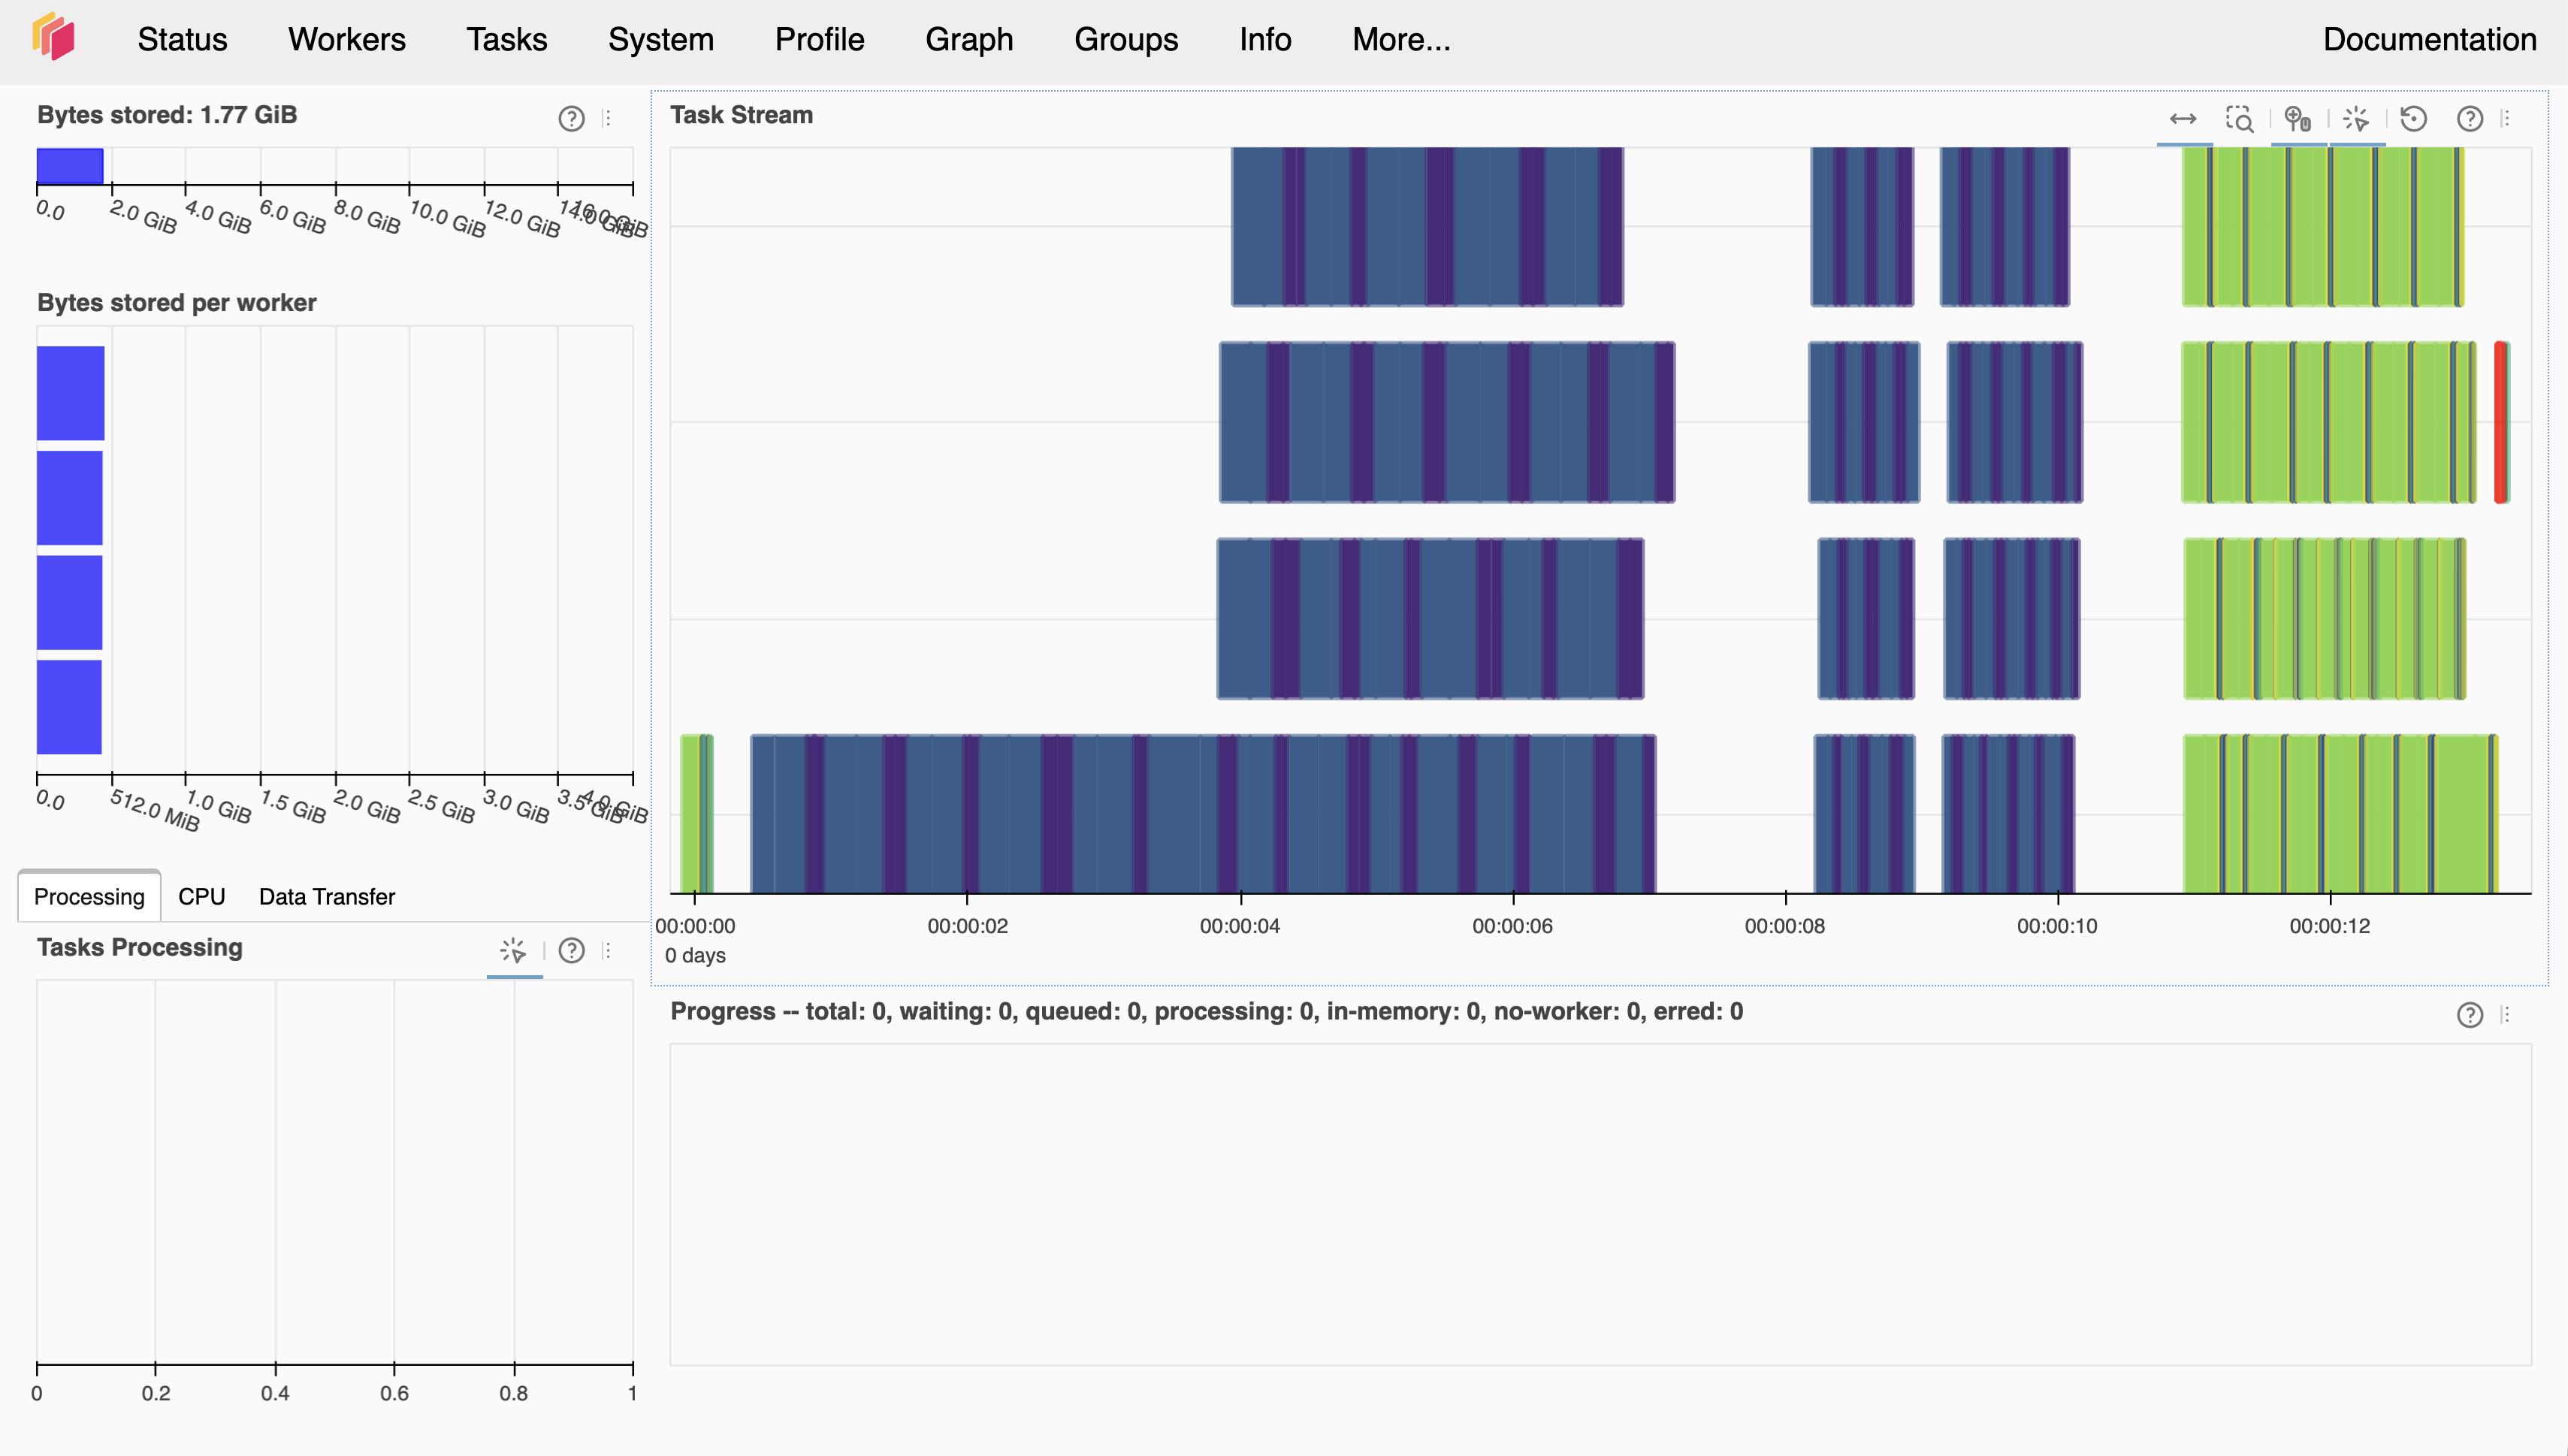

Any time we compute the catalog, the result is a `nested_pandas.NestedFrame`, which is a kind of `pandas.DataFrame`.

In [19]:
df = cat.head(5)
print(type(df))
import pandas as pd
print(isinstance(df, pd.DataFrame))

<class 'nested_pandas.nestedframe.core.NestedFrame'>
True


Everything looks right, so let's compute the whole catalog.

In [20]:
# Compute catalog and write to disk
cat.write_catalog('dp2_example_cat', overwrite=True)

In [21]:
# Compute catalog to dataframe
df = cat.compute()

In [22]:
df

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,,
2021882992298765515,6312.816406,21.899443,950.743286,269.492478,-31.944853,-1.893093
2021885912268212287,722.161804,24.253414,9836.803711,269.525976,-31.936126,2.611637
...,...,...,...,...,...,...
2031705077721711405,4065.324707,22.377262,22382.875,269.034297,-28.197348,1.705803
2031705083533379444,2860.475098,22.758905,19031.958984,269.032091,-28.197241,1.895132


In [23]:
# Read catalog from disk
cat = lsdb.open_catalog('dp2_example_cat')

### Further reading

[Documentation: `lsdb.Catalog.compute()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.compute.html)  
[Documentation: `lsdb.Catalog.write_catalog()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.write_catalog.html#lsdb.catalog.Catalog.write_catalog)  
[Documentation: `lsdb.open_catalog()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.open_catalog.html#lsdb.open_catalog)

## Crossmatching

We can combine two catalogs by [cross-matching](https://www.aanda.org/articles/aa/full_html/2017/11/aa30965-17/aa30965-17.html).

As an example, we'll cross-match the LSST catalog with the [Gaia catalog](https://data.lsdb.io/Gaia/Gaia_DR3_(US-East%2C_S3)). This example will be an over-simplification of the process that does not account for stellar motion over time (epoch propagation). For a more in-depth and accurate example, see [Tutorial: Astrometric epoch propagation](https://docs.lsdb.io/en/latest/tutorials/pre_executed/dp1-gaia-epoch-prop.html).  

In [24]:
gaia_cat = lsdb.open_catalog('https://data.lsdb.io/hats/gaia_dr3',
                            columns=['pmra', 'pmdec', 'parallax', 'phot_g_mean_mag'])

In [25]:
gaia_cat

,pmra,pmdec,parallax,phot_g_mean_mag,ra,dec
npartitions=2016,,,,,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 2, Pixel: 1",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...,...


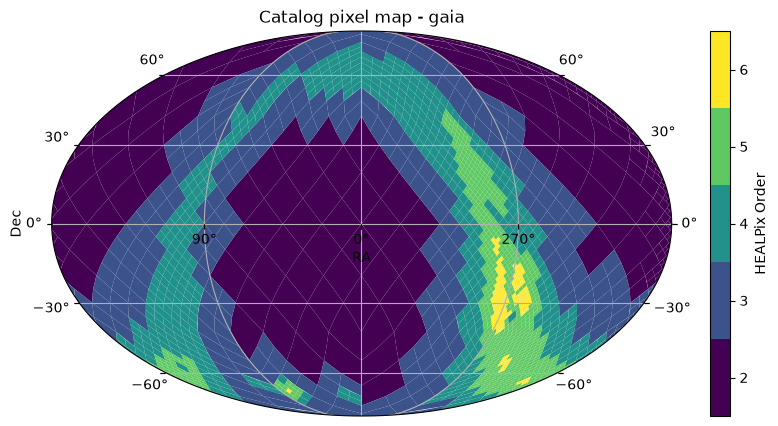

In [26]:
gaia_cat.plot_pixels();

In [27]:
x_cat = cat.crossmatch(gaia_cat, suffix_method='overlapping_columns')

In [28]:
x_cat.head()

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec,g_minus_r_mag,pmra,pmdec,parallax,phot_g_mean_mag,ra,dec,_dist_arcsec
_healpix_29,,,,,,,,,,,,,
2021882992298765515,6312.816406,21.899443,950.743286,269.492478,-31.944853,-1.893093,-6.806992,-8.206714,-0.607942,19.584293,269.492515,-31.944837,0.127476
2021885912268212287,722.161804,24.253414,9836.803711,269.525976,-31.936126,2.611637,<NA>,<NA>,<NA>,20.59597,269.525975,-31.936155,0.103917
2021885913480368752,1189.062744,23.711988,13368.254883,269.518602,-31.936637,2.419718,<NA>,<NA>,<NA>,20.520893,269.518581,-31.936606,0.127464
2021886052086887385,22559.029297,20.516699,95027.460938,269.499125,-31.911018,1.43803,-4.52914,-5.320255,-0.125586,18.61878,269.499285,-31.911012,0.490775
2021886089486228703,684.218628,24.312014,15117.708984,269.493208,-31.897396,3.095345,<NA>,<NA>,<NA>,20.443926,269.493215,-31.897357,0.141697


Let's check that the cross-matched catalog covers the correct sky region. Despite the Gaia catalog covering the whole sky, the cross-matched catalog should only contain the region that overlaps our filtered LSST catalog.

/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - object_lc_x_gaia'}>)

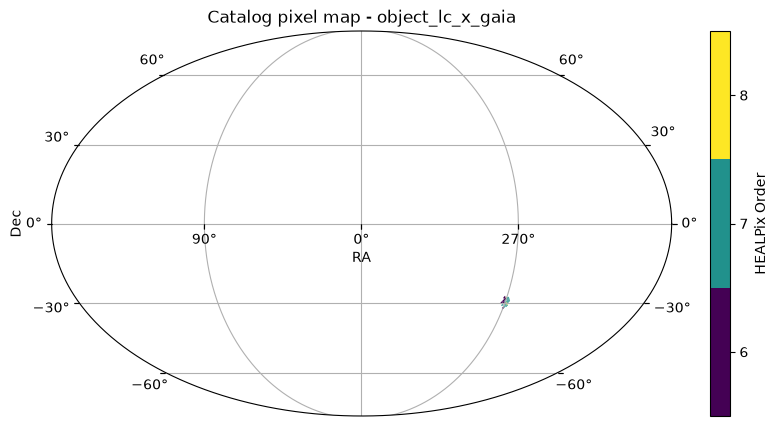

In [29]:
x_cat.plot_pixels()

There might also be extraneous matches, e.g. rows in the matched catalog that represent two different objects with similar coordinates, not one true object. As a quick check, the magnitudes reported from both catalogs should be close (differ by less than 1.0). Let's filter based on this criterion:

In [30]:
x_cat = cat.crossmatch(gaia_cat, suffix_method='overlapping_columns'
                      ).query('-1.0 < g_psfMag - phot_g_mean_mag < 1.0')

In [31]:
x_cat.head()

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec,g_minus_r_mag,pmra,pmdec,parallax,phot_g_mean_mag,ra,dec,_dist_arcsec
_healpix_29,,,,,,,,,,,,,
2021964496015623238,9673.453125,21.436047,42565.773438,270.967326,-30.960966,1.481665,<NA>,<NA>,<NA>,20.714178,270.967418,-30.960977,0.288048
2022006544697997495,120459.726562,18.697895,290390.96875,269.657039,-31.313142,0.879913,-1.077293,-1.839642,0.458377,17.735134,269.657049,-31.313134,0.041237
2022006726568729025,8043.849121,21.636341,37208.722656,269.679652,-31.294696,1.531636,<NA>,<NA>,<NA>,20.707853,269.679646,-31.29465,0.166786
2022006804832192246,6872.813477,21.807163,37648.890625,269.689101,-31.275892,1.70073,<NA>,<NA>,<NA>,21.011015,269.689088,-31.275955,0.228752
2022006908920589465,696306.875,16.792997,1653694.375,269.62221,-31.314808,0.864977,-1.84308,-12.179346,0.620065,15.840422,269.622216,-31.314774,0.121875


In [32]:
x_df = x_cat.compute()

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
/local/tmp/ipykernel_1321379/753833943.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\pi$ (Gaia)');


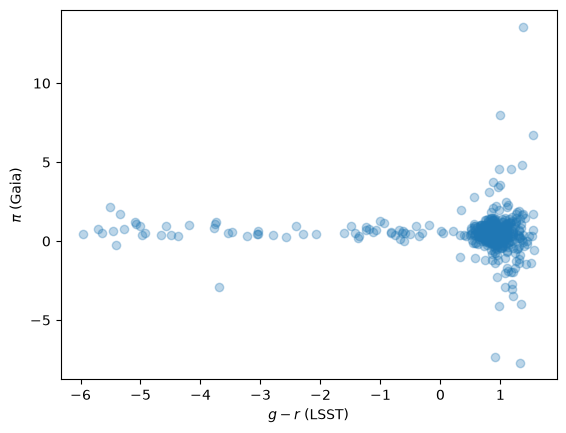

In [33]:
plt.scatter(x_df['g_minus_r_mag'], x_df['parallax'], alpha=0.3);
plt.xlabel('$g-r$ (LSST)');
plt.ylabel('$\pi$ (Gaia)');

### Further reading

[Tutorial: Astrometric epoch propagation](https://docs.lsdb.io/en/latest/tutorials/pre_executed/dp1-gaia-epoch-prop.html)  
[Documentation: `lsdb.Catalog.crossmatch()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.crossmatch.html#lsdb.catalog.Catalog.crossmatch)


## Close Dask client

In [34]:
client.close()